# Lab 08 — Recurrent Neural Networks: Forecasting COVID-19 Cases

**DSA 8401 — Applied Machine Learning**

### Learning goals
By the end of this lab you should be able to:
1. Explain why an RNN reads a sequence one step at a time, instead of all at once like an MLP.
2. Turn a time series into `(X, y)` windows for supervised learning.
3. Build and train a **SimpleRNN** forecaster.
4. Build and train an **LSTM** forecaster and explain why it usually beats a SimpleRNN.
5. Compare both models to a naive baseline using **MAE**.

**Core question:** Can a recurrent neural network predict tomorrow's case count better than
just guessing "tomorrow will look like today"?

**Dataset:** `Data/covid_19_data.csv` — daily COVID-19 case reports by country/region,
22 Jan 2020 to 29 May 2021 (Kaggle "Novel Corona Virus 2019 Dataset"). We use the **United
States** daily new confirmed cases as one clean, long time series.

In [1]:
# Step 1: Import the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# Make results repeatable
SEED = 42
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.18.0


## 1. Load and prepare the data

The raw file has one row per country/region per day, with a **cumulative** confirmed-case count.
We:
1. Keep only the **US** rows and sum them (some days have multiple state rows).
2. Take the **day-to-day difference** to get *new* cases per day.
3. Clip any negative values to 0 (case counts are sometimes corrected downward).
4. Smooth with a **7-day rolling average**, since reporting is uneven across the week
   (for example, fewer cases are reported on weekends).

In [2]:
# Step 2: Load the CSV and build a daily "new cases" series for the US
raw = pd.read_csv(r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\covid_19_data.csv")
raw["ObservationDate"] = pd.to_datetime(raw["ObservationDate"])

us = (raw[raw["Country/Region"] == "US"]
      .groupby("ObservationDate")["Confirmed"].sum()
      .sort_index())

new_cases = us.diff().clip(lower=0)          # cumulative -> daily new cases
new_cases = new_cases.rolling(7, min_periods=1).mean()   # smooth out weekday/weekend reporting
new_cases = new_cases.dropna()

print(f"Days: {len(new_cases)}  ({new_cases.index.min().date()} to {new_cases.index.max().date()})")
new_cases.head()

Days: 493  (2020-01-23 to 2021-05-29)


ObservationDate
2020-01-23    0.000000
2020-01-24    0.500000
2020-01-25    0.333333
2020-01-26    1.000000
2020-01-27    0.800000
Name: Confirmed, dtype: float64

In [5]:
new_cases

ObservationDate
2020-01-23        0.000000
2020-01-24        0.500000
2020-01-25        0.333333
2020-01-26        1.000000
2020-01-27        0.800000
                  ...     
2021-05-25    24155.285714
2021-05-26    23406.571429
2021-05-27    23032.857143
2021-05-28    22122.428571
2021-05-29    21007.857143
Name: Confirmed, Length: 493, dtype: float64

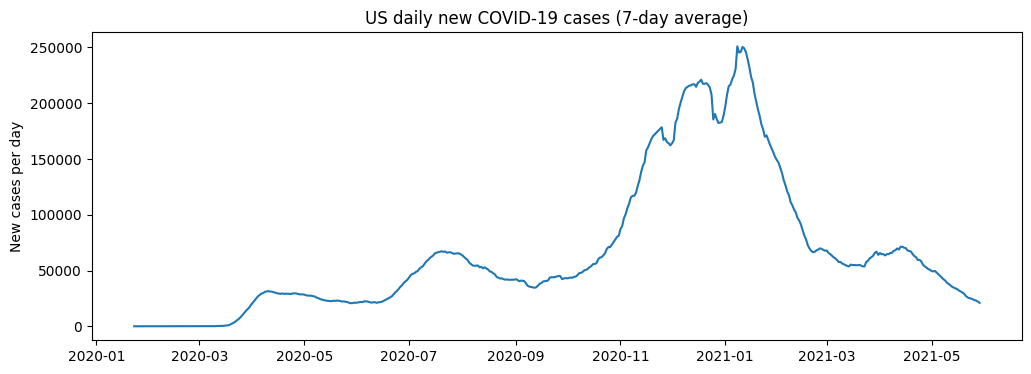

In [6]:
# Step 3: Plot the series -- always look before modelling
plt.figure(figsize=(12, 4))
plt.plot(new_cases.index, new_cases.values)
plt.title("US daily new COVID-19 cases (7-day average)")
plt.ylabel("New cases per day")
plt.show()

## 2. Split into train and test by time

We hold out the **last 60 days** as a test set. The model must never see the future during
training, so we split by date, not randomly.

In [7]:
# Step 4: Train / test split
TEST_DAYS = 60

train_series = new_cases.iloc[:-TEST_DAYS]
test_series  = new_cases.iloc[-TEST_DAYS:]

print(f"Train: {len(train_series)} days ({train_series.index.min().date()} to {train_series.index.max().date()})")
print(f"Test:  {len(test_series)} days ({test_series.index.min().date()} to {test_series.index.max().date()})")

Train: 433 days (2020-01-23 to 2021-03-30)
Test:  60 days (2021-03-31 to 2021-05-29)


## 3. Scale the data

RNNs train better when inputs are on a small, consistent scale. We use **MinMaxScaler** to squeeze
values into `[0, 1]`.

As always: **fit** the scaler on training data only, then **transform** both sets with it.

In [8]:
# Step 5: Scale to [0, 1]
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).ravel()
test_scaled  = scaler.transform(test_series.values.reshape(-1, 1)).ravel()

print("Train scaled range:", train_scaled.min().round(3), "to", train_scaled.max().round(3))
print("Test scaled range: ", test_scaled.min().round(3), "to", test_scaled.max().round(3))

Train scaled range: 0.0 to 1.0
Test scaled range:  0.084 to 0.284


## 4. Windowing: turn the series into `(X, y)` examples

An RNN forecaster looks at the last **14 days** and predicts the **next single day**:

```
[d1 d2 d3 ................. d14] -> [d15]
   [d2 d3 ................. d15] -> [d16]
      [d3 ................. d16] -> [d17]
```

`X` has shape `(n_windows, 14, 1)` — one value per day, one day at a time. `y` has shape
`(n_windows,)` — the single next value.

We build windows separately inside `train_scaled` and `test_scaled`. This means the first 14
days of the test set are only used as *input* (to start the window) — we do not score a
prediction for them.

In [9]:
# Step 6: Build sliding windows
LOOKBACK = 14   # days of history the model sees

def make_windows(series, lookback):
    X, y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i:i + lookback])
        y.append(series[i + lookback])
    X = np.array(X).reshape(-1, lookback, 1)   # (n, 14, 1) -- RNNs expect a 3D input
    y = np.array(y)
    return X, y


X_train, y_train = make_windows(train_scaled, LOOKBACK)
X_test,  y_test  = make_windows(test_scaled, LOOKBACK)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)

X_train: (419, 14, 1)  y_train: (419,)
X_test:  (46, 14, 1)  y_test:  (46,)


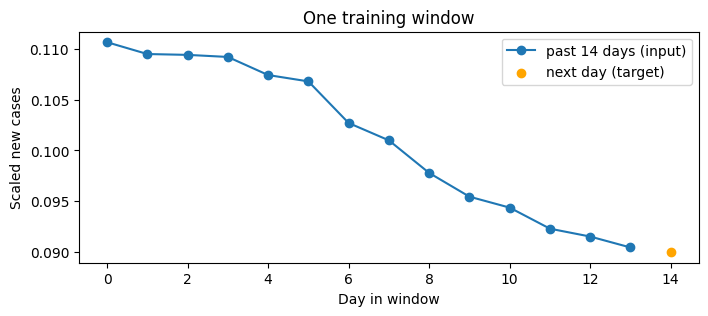

In [7]:
# Step 7: Look at one window
plt.figure(figsize=(8, 3))
plt.plot(range(LOOKBACK), X_train[100, :, 0], marker="o", label="past 14 days (input)")
plt.scatter([LOOKBACK], [y_train[100]], color="orange", zorder=5, label="next day (target)")
plt.title("One training window")
plt.xlabel("Day in window")
plt.ylabel("Scaled new cases")
plt.legend()
plt.show()

## 5. A naive baseline

Before training anything: how good is just guessing **"tomorrow = today"**? Any model we build
must beat this to be worth the extra complexity.

In [10]:
# Step 8: Naive baseline -- predict the last value in each window
def to_units(scaled_values):
    return scaler.inverse_transform(scaled_values.reshape(-1, 1)).ravel()


results = {}   # test MAE (real units: cases per day) for every model

naive_pred = X_test[:, -1, 0]                       # "today's" value, i.e. last day in the window
results["Naive (today = tomorrow)"] = mean_absolute_error(to_units(y_test), to_units(naive_pred))

print(f"Naive baseline test MAE: {results['Naive (today = tomorrow)']:,.0f} cases/day")

Naive baseline test MAE: 1,118 cases/day


## 6. Build a SimpleRNN forecaster

A **SimpleRNN** reads the 14 days one at a time, updating a small memory (its hidden state) at
each step. After the last day, a `Dense(1)` layer turns that memory into a single prediction.

Architecture: **Input (14 days x 1 feature) -> SimpleRNN(32) -> Dense(1)**

In [9]:
# Step 9: Define and compile the SimpleRNN
keras.utils.set_random_seed(SEED)   # reset so this model's init/training is reproducible on its own

rnn = keras.Sequential([
    keras.Input(shape=(LOOKBACK, 1)),
    layers.SimpleRNN(32),
    layers.Dense(1),
])

rnn.compile(optimizer="adam", loss="mae")
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epochs trained: 50


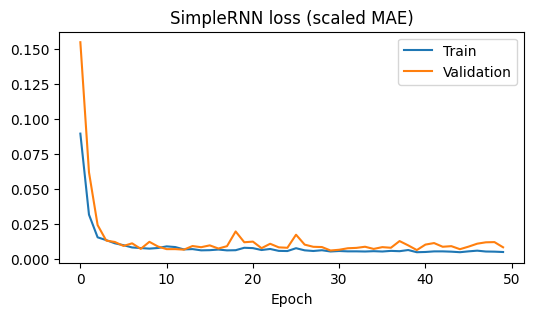

In [10]:
# Step 10: Train with early stopping
# start_from_epoch gives training a head start before early stopping can kick in --
# with only ~60 validation windows, val_loss is noisy in the first few epochs.
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, start_from_epoch=20, restore_best_weights=True
)

history_rnn = rnn.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
)
print("Epochs trained:", len(history_rnn.history["loss"]))

plt.figure(figsize=(6, 3))
plt.plot(history_rnn.history["loss"], label="Train")
plt.plot(history_rnn.history["val_loss"], label="Validation")
plt.title("SimpleRNN loss (scaled MAE)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [11]:
# Step 11: Evaluate the SimpleRNN on the test set
rnn_pred = rnn.predict(X_test, verbose=0).ravel()
results["SimpleRNN"] = mean_absolute_error(to_units(y_test), to_units(rnn_pred))

print(f"SimpleRNN test MAE: {results['SimpleRNN']:,.0f} cases/day")

SimpleRNN test MAE: 677 cases/day


## 7. Build an LSTM forecaster

A plain SimpleRNN tends to "forget" what happened many steps ago -- its memory is overwritten at
every step. An **LSTM (Long Short-Term Memory)** adds gates that learn what to keep, what to
forget, and what to write to memory, which usually makes it better at longer sequences.

Same architecture, different recurrent layer: **Input (14 days x 1) -> LSTM(16) -> Dense(1)**
(a smaller layer than the SimpleRNN -- the LSTM's gates already give it more parameters per unit).

In [12]:
# Step 12: Define, compile and train the LSTM
keras.utils.set_random_seed(SEED)   # reset again, so the comparison with SimpleRNN is fair

lstm = keras.Sequential([
    keras.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(16),
    layers.Dense(1),
])
lstm.compile(optimizer="adam", loss="mae")

history_lstm = lstm.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, start_from_epoch=20, restore_best_weights=True
    )],
    verbose=0,
)
print("Epochs trained:", len(history_lstm.history["loss"]))

Epochs trained: 108


In [13]:
# Step 13: Evaluate the LSTM on the test set
lstm_pred = lstm.predict(X_test, verbose=0).ravel()
results["LSTM"] = mean_absolute_error(to_units(y_test), to_units(lstm_pred))

print(f"LSTM test MAE: {results['LSTM']:,.0f} cases/day")

LSTM test MAE: 972 cases/day


## 8. Build a GRU forecaster

A **GRU (Gated Recurrent Unit)** is a simplified LSTM: it merges the LSTM's three gates into two,
so it has fewer parameters and trains faster, while often matching or beating LSTM in accuracy.

Same idea, one more recurrent layer to compare: **Input (14 days x 1) -> GRU(16) -> Dense(1)**

In [14]:
# Step 14: Define, compile and train the GRU
keras.utils.set_random_seed(SEED)   # reset again, so all three models are compared fairly

gru = keras.Sequential([
    keras.Input(shape=(LOOKBACK, 1)),
    layers.GRU(16),
    layers.Dense(1),
])
gru.compile(optimizer="adam", loss="mae")

history_gru = gru.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, start_from_epoch=20, restore_best_weights=True
    )],
    verbose=0,
)
print("Epochs trained:", len(history_gru.history["loss"]))

Epochs trained: 200


In [15]:
# Step 15: Evaluate the GRU on the test set
gru_pred = gru.predict(X_test, verbose=0).ravel()
results["GRU"] = mean_absolute_error(to_units(y_test), to_units(gru_pred))

print(f"GRU test MAE: {results['GRU']:,.0f} cases/day")

GRU test MAE: 582 cases/day


## 9. Compare all models

                          Test MAE (cases/day)
Naive (today = tomorrow)                1118.0
SimpleRNN                                677.0
LSTM                                     972.0
GRU                                      582.0


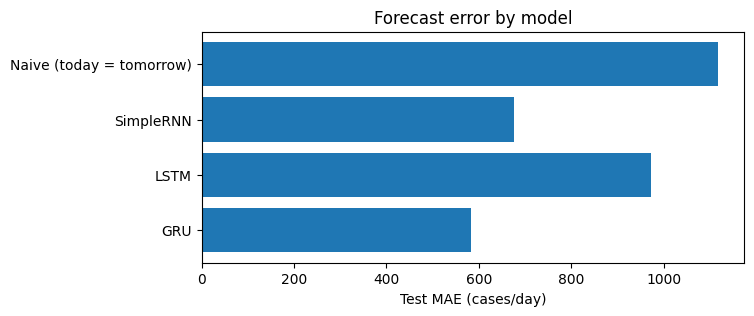

In [16]:
# Step 16: Final comparison table and chart (lower MAE is better)
summary = pd.Series(results, name="Test MAE (cases/day)").round(0).to_frame()
print(summary)

plt.figure(figsize=(7, 3))
plt.barh(summary.index, summary["Test MAE (cases/day)"])
plt.gca().invert_yaxis()
plt.xlabel("Test MAE (cases/day)")
plt.title("Forecast error by model")
plt.show()

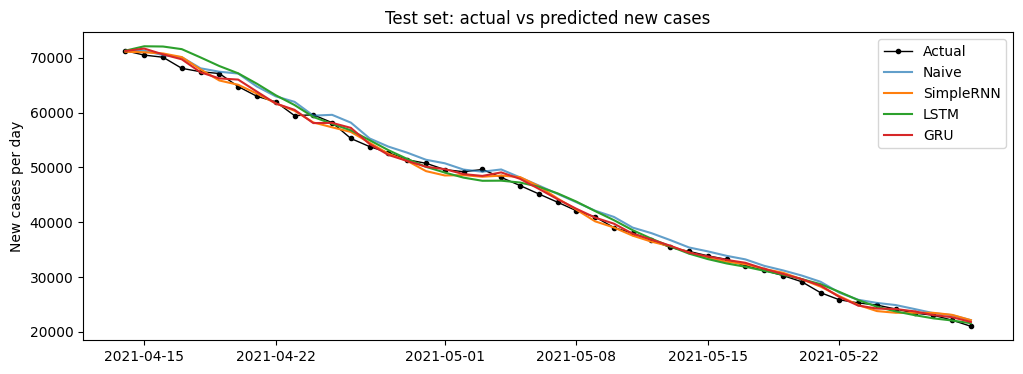

In [17]:
# Step 17: Plot actual vs predicted for the test period
test_dates = test_series.index[LOOKBACK:]     # first LOOKBACK days had no prediction

plt.figure(figsize=(12, 4))
plt.plot(test_dates, to_units(y_test), "k.-", label="Actual", lw=1)
plt.plot(test_dates, to_units(naive_pred), label="Naive", alpha=0.7)
plt.plot(test_dates, to_units(rnn_pred), label="SimpleRNN")
plt.plot(test_dates, to_units(lstm_pred), label="LSTM")
plt.plot(test_dates, to_units(gru_pred), label="GRU")
plt.title("Test set: actual vs predicted new cases")
plt.ylabel("New cases per day")
plt.legend()
plt.show()

All three beat the naive baseline, but the ranking among them is not fixed. The extra gates in
an LSTM or GRU do not automatically win on a single, fairly short, smooth series like this one --
they are more parameters to learn without much more signal to learn from. The lesson: **try the
simpler model too**, and let the test-set score decide, rather than assuming the fancier
architecture is always better.

## 10. Summary

### What should you remember?

1. **Always beat a baseline.** "Tomorrow = today" is a surprisingly strong forecaster for a
   smooth series — any RNN worth using must clearly beat it.
2. **Windowing** turns a series into `(lookback, 1)` inputs and single-value targets. Split by
   **time**, and fit the scaler on training data only.
3. A **SimpleRNN** reads a sequence step by step, carrying a small memory forward.
4. An **LSTM** adds three gates that control what to remember, forget and output. This tends to
   help most on longer or more complex sequences -- on a short, simple series it can add
   parameters without adding accuracy, as we saw here.
5. A **GRU** simplifies the LSTM to two gates. It usually trains faster and performs comparably,
   which is why it's a common first choice before reaching for a full LSTM.
6. Report error in **real units** (cases/day here), not the scaled `[0, 1]` value
 that is
   what a decision-maker actually cares about.